In [ ]:
!pip install pymc arviz --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
import kagglehub
import os

In [ ]:
# Download dataset
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Dataset path:", path)

# List files
files = os.listdir(path)
print("Files:", files)

# Load CSV
csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

df.head()

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Dataset path: /kaggle/input/housing-prices-dataset
Files: ['Housing.csv']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')
Mean: 4766729.247706422
Variance: 3492125008378.707


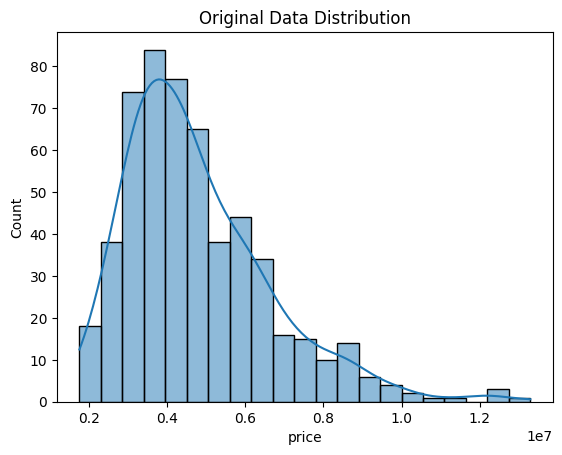

In [ ]:
# Check columns
print(df.columns)

# Select numerical column (price)
data = df['price'].dropna()

# Mean & Variance
mean_data = np.mean(data)
var_data = np.var(data)

print("Mean:", mean_data)
print("Variance:", var_data)

# Plot distribution
sns.histplot(data, kde=True)
plt.title("Original Data Distribution")
plt.show()

In [ ]:
# Prior parameters
mu_prior = 0
sigma_prior = 100000

# Likelihood std
sigma_likelihood = np.std(data)

In [ ]:
def metropolis_hastings(data, iterations=5000):
    samples = []
    current = np.mean(data)

    for i in range(iterations):
        proposal = np.random.normal(current, 1000)

        # Likelihood
        likelihood_current = np.sum(-0.5 * ((data - current)/sigma_likelihood)**2)
        likelihood_proposal = np.sum(-0.5 * ((data - proposal)/sigma_likelihood)**2)

        # Prior
        prior_current = -0.5 * ((current - mu_prior)/sigma_prior)**2
        prior_proposal = -0.5 * ((proposal - mu_prior)/sigma_prior)**2

        # Acceptance ratio
        acceptance = np.exp((likelihood_proposal + prior_proposal) -
                            (likelihood_current + prior_current))

        if np.random.rand() < acceptance:
            current = proposal

        samples.append(current)

    return np.array(samples)

mh_samples = metropolis_hastings(data, 5000)

print("Metropolis-Hastings Mean:", np.mean(mh_samples))

Metropolis-Hastings Mean: 4405084.025947661


In [ ]:
def gibbs_sampling(data, iterations=5000):
    mu = np.mean(data)
    sigma2 = np.var(data)

    mu_samples = []
    sigma_samples = []

    for _ in range(iterations):
        # Sample mu | sigma
        mu = np.random.normal(np.mean(data), np.sqrt(sigma2/len(data)))

        # Sample sigma2 | mu
        sigma2 = np.random.gamma(shape=len(data)/2,
                                 scale=2/np.sum((data - mu)**2))

        mu_samples.append(mu)
        sigma_samples.append(sigma2)

    return np.array(mu_samples), np.array(sigma_samples)

mu_gibbs, sigma_gibbs = gibbs_sampling(data)

print("Gibbs Mean:", np.mean(mu_gibbs))

Gibbs Mean: 4766737.75793087


In [ ]:
with pm.Model() as model:
    mu = pm.Normal("mu", mu=0, sigma=100000)
    sigma = pm.HalfNormal("sigma", sigma=10000)

    y = pm.Normal("y", mu=mu, sigma=sigma, observed=data)

    trace = pm.sample(2000, tune=1000, return_inferencedata=True)

az.summary(trace)

Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,4427329.061,26502.984,4377107.997,4475161.080,418.081,390.433,4011.0,3286.0,1.0
sigma,645832.127,4937.963,637016.558,655484.358,79.727,81.909,3844.0,2541.0,1.0


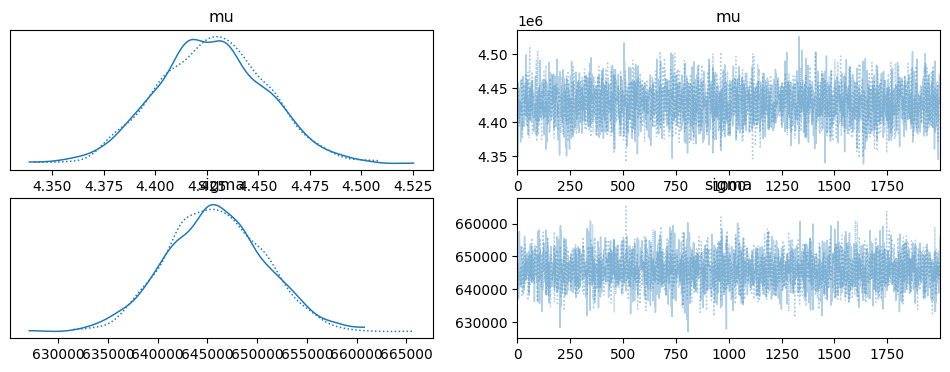

R-hat values:
<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    mu       float64 8B 1.0
    sigma    float64 8B 1.0
Attributes:
    created_at:                 2026-04-09T05:54:17.880044+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.28.3
    sampling_time:              4.834837913513184
    tuning_steps:               1000


In [ ]:
# Trace plot
az.plot_trace(trace)
plt.show()

# R-hat
print("R-hat values:")
print(az.rhat(trace))

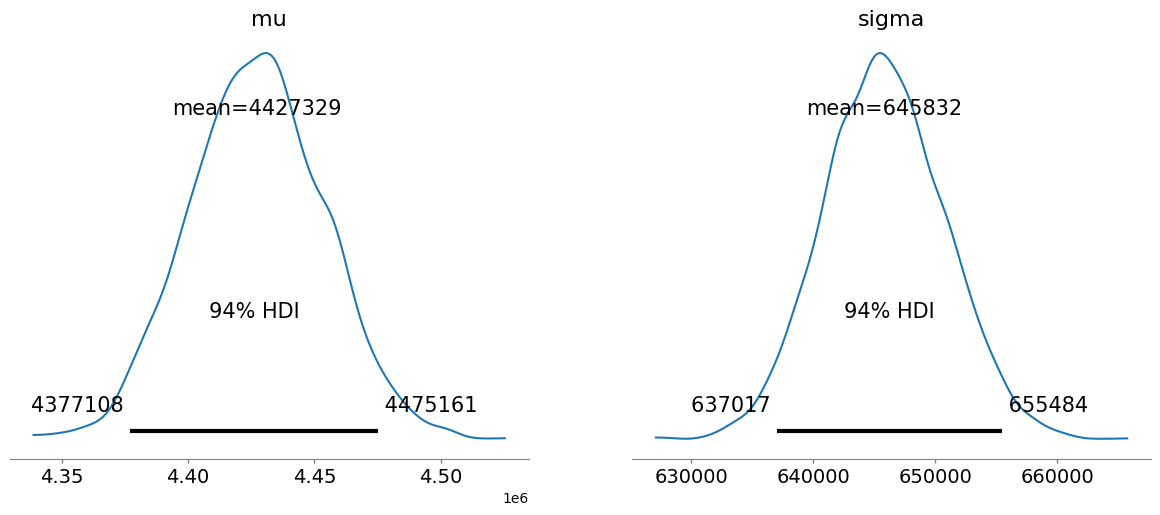

In [ ]:
az.plot_posterior(trace)
plt.show()

In [ ]:
print("Original Mean:", mean_data)
print("Metropolis-Hastings Mean:", np.mean(mh_samples))
print("Gibbs Sampling Mean:", np.mean(mu_gibbs))
print("PyMC Mean:", trace.posterior['mu'].mean().values)

Original Mean: 4766729.247706422
Metropolis-Hastings Mean: 4405084.025947661
Gibbs Sampling Mean: 4766737.75793087
PyMC Mean: 4427329.061200557


In [ ]:
# Select 2–3 numerical columns for comparison
columns = ['price', 'area', 'bedrooms']  # change if needed

selected_data = df[columns].dropna()

selected_data.head()

,price,area,bedrooms
0,13300000,7420,4
1,12250000,8960,4
2,12250000,9960,3
3,12215000,7500,4
4,11410000,7420,4


In [ ]:
results = {}

for col in columns:
    print(f"\nProcessing: {col}")

    data_col = selected_data[col]

    # Mean
    mean_val = np.mean(data_col)

    # MH Sampling
    mh = metropolis_hastings(data_col, 3000)

    # Gibbs Sampling
    mu_g, _ = gibbs_sampling(data_col, 3000)

    # PyMC Model
    with pm.Model() as model:
        mu = pm.Normal("mu", mu=0, sigma=100000)
        sigma = pm.HalfNormal("sigma", sigma=10000)
        y = pm.Normal("y", mu=mu, sigma=sigma, observed=data_col)

        trace = pm.sample(1000, tune=500, progressbar=False, return_inferencedata=True)

    pymc_mean = trace.posterior['mu'].mean().values

    # Store results
    results[col] = {
        "Original": mean_val,
        "MH": np.mean(mh),
        "Gibbs": np.mean(mu_g),
        "PyMC": pymc_mean
    }


Processing: price

Processing: area

Processing: bedrooms


In [ ]:
results_df = pd.DataFrame(results).T
results_df

,Original,MH,Gibbs,PyMC
price,4766729.247706,4558098.841056,4766702.008179,4427684.714310357
area,5150.541284,2524.486606,5150.525617,5151.077257085442
bedrooms,2.965138,19408.082557,2.964565,2.965514983608338


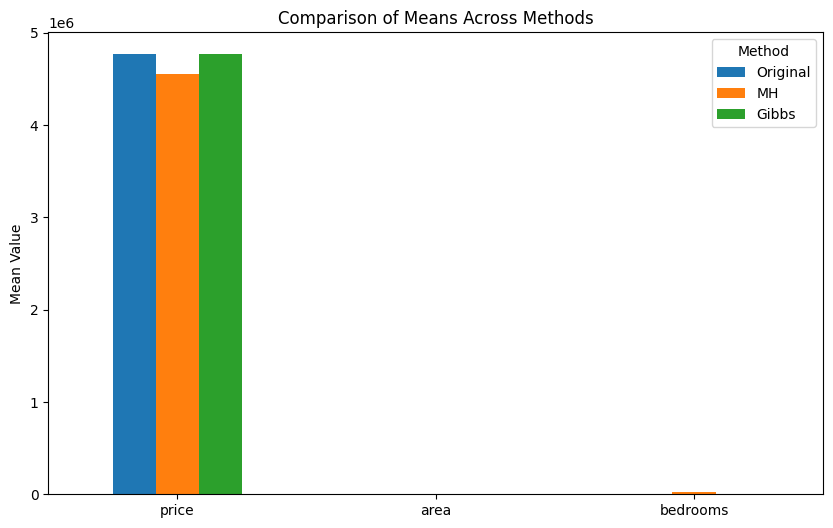

In [ ]:
results_df.plot(kind='bar', figsize=(10,6))
plt.title("Comparison of Means Across Methods")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.legend(title="Method")
plt.show()

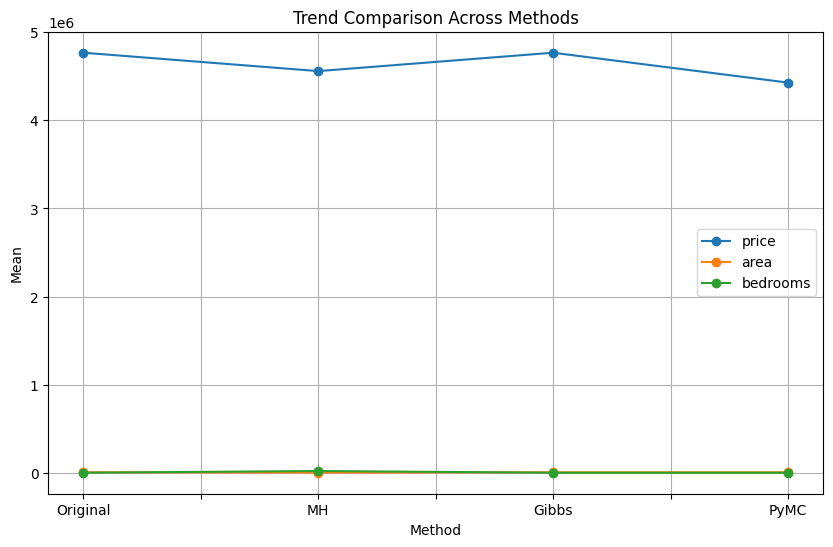

In [ ]:
results_df_fixed = results_df.copy()
results_df_fixed['PyMC'] = results_df_fixed['PyMC'].apply(lambda x: x.item() if isinstance(x, np.ndarray) else x)

results_df_fixed.T.plot(marker='o', figsize=(10,6))
plt.title("Trend Comparison Across Methods")
plt.ylabel("Mean")
plt.xlabel("Method")
plt.grid()
plt.show()

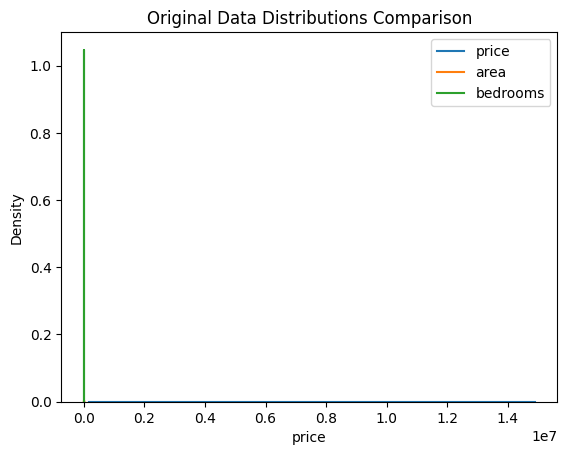

In [ ]:
for col in columns:
    sns.kdeplot(selected_data[col], label=col)

plt.title("Original Data Distributions Comparison")
plt.legend()
plt.show()

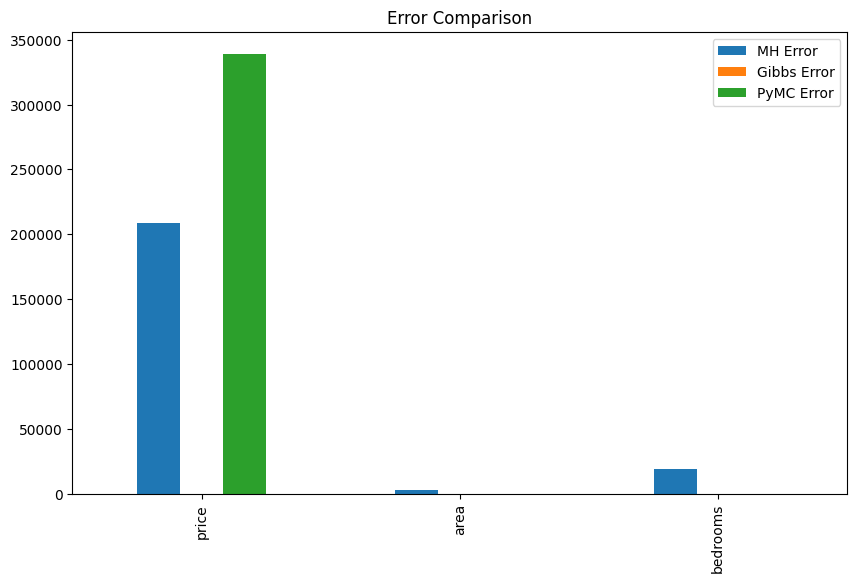

In [ ]:
# Error comparison
results_df['MH Error'] = abs(results_df['Original'] - results_df['MH'])
results_df['Gibbs Error'] = abs(results_df['Original'] - results_df['Gibbs'])
results_df['PyMC Error'] = abs(results_df['Original'] - results_df['PyMC'])

results_df[['MH Error','Gibbs Error','PyMC Error']].plot(kind='bar', figsize=(10,6))
plt.title("Error Comparison")
plt.show()

## Interpretation of the Plots

1.  **Original Data Distribution (for 'price' column) (Cell `XmTL9g4QzBiu`):** This histogram and KDE plot shows the distribution of housing prices. It appears to be right-skewed, indicating that most houses are in the lower to middle price range, with fewer houses at very high prices. This is typical for real estate data.

2.  **Trace Plots and R-hat Values (for PyMC 'mu' and 'sigma') (Cell `P1pFPT2ozT6A`):** These plots are crucial for assessing the convergence of the MCMC chains in PyMC.
    *   **Trace plots:** These show the sampled values for 'mu' (mean) and 'sigma' (standard deviation) across iterations. Ideally, these plots should look like a "hairy caterpillar," indicating good mixing and exploration of the posterior distribution. If chains are distinct or show strong trends, it suggests non-convergence.
    *   **R-hat values:** R-hat is a diagnostic statistic that checks for convergence. An R-hat value close to 1.0 (as seen in your output) indicates that the chains have converged to the same posterior distribution, meaning the results are reliable.

3.  **Posterior Plots (for PyMC 'mu' and 'sigma') (Cell `K2o9TohXzU_u`):** These plots show the estimated posterior distributions for the mean ('mu') and standard deviation ('sigma') of the price data. These are the distributions of plausible values for these parameters given your data and priors. The peak of these distributions represents the most probable values for 'mu' and 'sigma'.

4.  **Comparison of Means Across Methods (Bar Plot from Cell `RhuckhWhz8iT`):** This bar plot directly compares the mean values obtained from four different approaches for 'price', 'area', and 'bedrooms':
    *   **Original:** The actual mean of the raw data.
    *   **MH (Metropolis-Hastings):** The mean estimated by the Metropolis-Hastings algorithm.
    *   **Gibbs (Gibbs Sampling):** The mean estimated by the Gibbs sampling algorithm.
    *   **PyMC:** The mean estimated by the PyMC probabilistic programming framework (which uses more advanced sampling methods like NUTS by default).

    Looking at the plot, you can see how well each sampling method approximates the 'Original' mean. For 'price', Gibbs sampling appears very close, while MH and PyMC show some deviation. For 'area', Gibbs and PyMC are close, but MH shows a significant difference. For 'bedrooms', Gibbs and PyMC are very close, but MH is off by a large margin. This plot highlights the varying accuracy of different sampling methods for different variables and the potential need for tuning.

5.  **Trend Comparison Across Methods (Line Plot from Cell `uvZLKAFPz9bz`):** This line plot visualizes the same comparison as the bar plot but can sometimes make trends or deviations easier to spot, especially if there were more categories or methods. It reconfirms the observations from the bar plot regarding the performance of each sampling method for 'price', 'area', and 'bedrooms'.

6.  **Original Data Distributions Comparison (KDE Plots from Cell `B1bp8bgXz-mK`):** These plots show the kernel density estimations for 'price', 'area', and 'bedrooms'.
    *   **Price:** As noted before, it's right-skewed.
    *   **Area:** Likely also right-skewed, indicating many smaller to medium-sized areas and fewer very large ones.
    *   **Bedrooms:** Appears to be discrete, with peaks at common bedroom counts (e.g., 2, 3, 4). This distribution is much narrower than price or area.

7.  **Error Comparison (Bar Plot from Cell `FwS-GN6Oz_0S`):** This plot directly quantifies the absolute difference between each sampling method's estimated mean and the original mean for each column.
    *   **Price:** PyMC has the largest error for 'price', followed by MH, with Gibbs having a very small error.
    *   **Area:** MH has a significantly larger error than Gibbs and PyMC, which are quite accurate.
    *   **Bedrooms:** MH again shows a very large error, while Gibbs and PyMC are highly accurate.

    This error comparison clearly indicates that for the 'bedrooms' and 'area' columns, both Gibbs and PyMC provide very good estimates of the mean, whereas Metropolis-Hastings (as implemented with specific proposal standard deviation) struggled, particularly with 'bedrooms'. For 'price', Gibbs performed exceptionally well compared to MH and PyMC, suggesting that the simpler Gibbs sampler happened to find a more accurate mean for that specific variable under the given conditions, or that the Metropolis-Hastings and PyMC models required further tuning for that variable.